<a href="https://colab.research.google.com/github/Nikita11811/DH_Programming_26/blob/main/Linev_Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Это лабораторная работа Никиты Линева по тексту 5.txt ⛽

In [15]:
import re
import requests
import nltk
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt
!pip install pymorphy3
from pymorphy3 import MorphAnalyzer
nltk.download('stopwords')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 59.5 MB/s eta 0:00:00


In [36]:
with open("5.txt", "r", encoding="utf-8") as file:
    text = file.read()

In [58]:
def clean_text(text):
    text = text.lower()

    text = re.sub(r'\n+', ' ', text)

    # уберем табы
    text = re.sub(r'\t+', ' ', text)

    # оставим только кириллицу
    text = re.sub(r'[^а-яё\s]', ' ', text)

    # уберем лишние пробелы
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

cleaned_text = clean_text(text)

In [59]:
tokens = re.findall(r'\w+', cleaned_text)

print(f"Всего токенов: {len(tokens)}")
print(f"Уникальных токенов: {len(set(tokens))}")

Всего токенов: 44122
Уникальных токенов: 13744


In [60]:
morph = MorphAnalyzer()

lemmas = [morph.parse(token)[0].normal_form for token in tokens]

print("Посмотрим:")
print(lemmas[:50])

Посмотрим:
['говорить', 'ты', 'пожалуйста', 'внятный', 'вразумительный', 'говорить', 'да', 'я', 'ведь', 'и', 'то', 'ты', 'слухать', 'уж', 'я', 'рада', 'бы', 'конь', 'перенять', 'это', 'она', 'то', 'ись', 'он', 'говорить', 'повилика', 'у', 'конь', 'нога', 'спутать', 'что', 'за', 'повилика', 'такой', 'это', 'вроде', 'как', 'трава', 'такой', 'есть', 'повитель', 'ну', 'ну', 'повилика', 'у', 'конь', 'нога', 'спутать', 'студёный', 'роса']


In [61]:
russian_stopwords = set(stopwords.words('russian'))

filtered_lemmas = [
    lemma for lemma in lemmas
    if lemma not in russian_stopwords and len(lemma) > 2
]

print(f"Осталось токенов: {len(filtered_lemmas)}")
print(f"Уникальных: {len(set(filtered_lemmas))}")

Осталось токенов: 27394
Уникальных: 7808


In [62]:
from collections import Counter

freq = Counter(filtered_lemmas)

print("Топ-20 самых частых слов:")
for word, count in freq.most_common(20):
    print(word, count)

Топ-20 самых частых слов:
это 307
варя 259
свой 229
всё 181
илья 177
петрович 169
сказать 168
тутолмин 167
захар 161
иванович 159
рука 134
который 109
говорить 106
весь 92
лицо 91
произнести 87
мочь 84
песня 79
мокей 77
снова 76


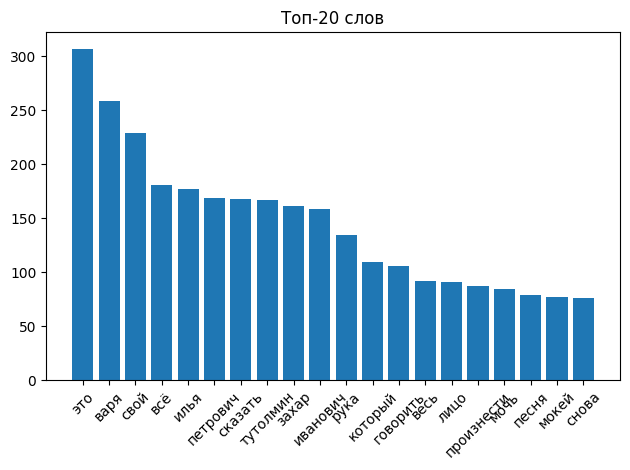

In [83]:
top_words = freq.most_common(20)

words = [w for w, c in top_words]
counts = [c for w, c in top_words]

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Топ-20 слов")
plt.tight_layout()
plt.show()

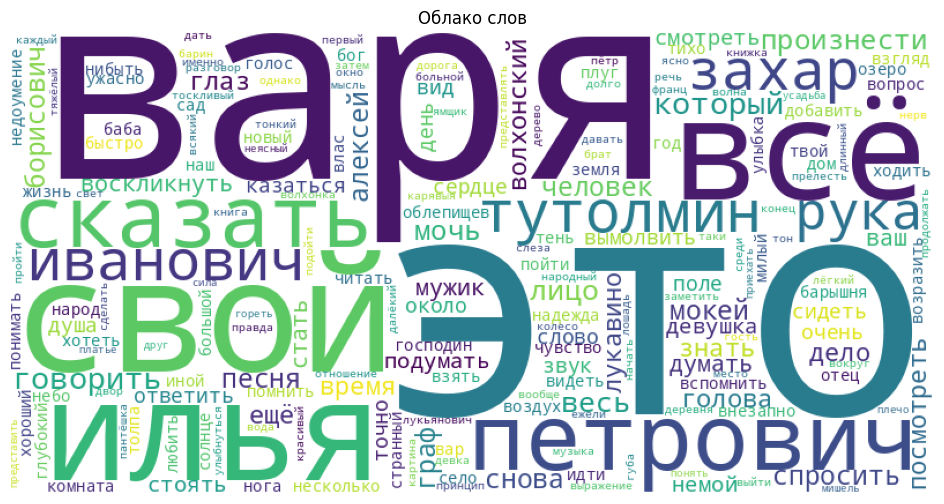

In [63]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate_from_frequencies(freq)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Облако слов")
plt.show()

In [98]:
pos_counts = Counter()

for token in tokens:
    pos = morph.parse(token)[0].tag.POS
    pos_counts[pos] += 1

top_pos = pos_counts.most_common(10)
print("Части речи:")
for pos, count in top_pos:
    print(pos, count)

Части речи:
NOUN 11793
VERB 6505
CONJ 5167
ADJF 5063
PREP 4474
NPRO 3575
ADVB 2971
PRCL 2072
INFN 698
PRTF 490


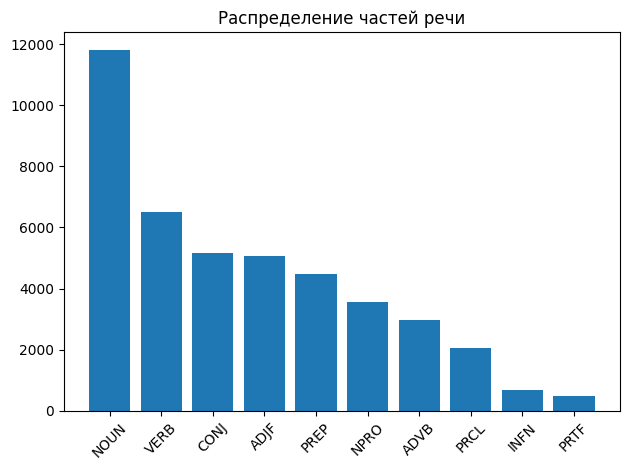

In [106]:
pos = dict(top_pos).keys()
values = dict(top_pos).values()

plt.figure()
plt.bar(pos, values)
plt.title("Распределение частей речи")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [65]:
total = sum(pos_counts.values())

print("\nДоли частей речи:")
for pos, count in pos_counts.most_common(5):
    print(f"{pos}: {round(count / total, 3)}")


Доли частей речи:
NOUN: 0.267
VERB: 0.147
CONJ: 0.117
ADJF: 0.115
PREP: 0.101


In [66]:
tense_counts = Counter()

for token in tokens:
    p = morph.parse(token)[0]

    if p.tag.POS == 'VERB':
        tense = p.tag.tense
        if tense:
            tense_counts[tense] += 1

print("Времена глаголов:")
for tense, count in tense_counts.items():
    print(tense, count)

Времена глаголов:
past 4979
pres 893
futr 334


In [67]:
case_counts = Counter()

for token in tokens:
    p = morph.parse(token)[0]

    if p.tag.POS == 'NOUN':
        case = p.tag.case
        if case:
            case_counts[case] += 1

print("Падежи существительных:")
for case, count in case_counts.items():
    print(case, count)

Падежи существительных:
nomn 4317
gent 2758
ablt 1422
accs 1634
loct 1028
datv 586
loc2 27
gen2 12
voct 9


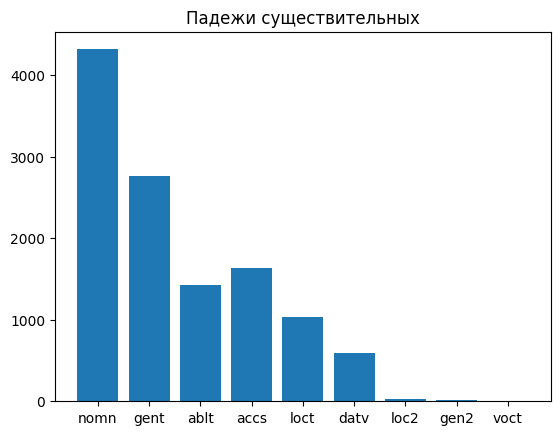

In [93]:
plt.figure()
plt.bar(case_counts.keys(), case_counts.values())
plt.title("Падежи существительных")
plt.show()

Теперь бахнем анализ ключевых слов по TF-IDF

In [70]:
def split_by_chapters(text):
    # разделим на главы по римским цифрам
    chapters = re.split(r'\n\s*[IVXLCDM]+\s*\n', text)

    # пустые -- в помоечку
    chapters = [ch.strip() for ch in chapters if len(ch.strip()) > 100]

    return chapters

documents = split_by_chapters(text)

print(f"Количество глав: {len(documents)}")
print("\nФрагмент первой главы:\n")
print(documents[0][:300])

Количество глав: 20

Фрагмент первой главы:

...-- Говори ты, пожалуйста, повнятнее... повразумительней говори!
   -- Да я ведь и то... Ты слухай:
  
   Уж я рада бы коня переняла,--
  
   это она, то ись, ему говорит --
  
   Повиликой у коня ноги спутанные...
  
   -- Что за повилика такая?
   -- Это вроде как трава такая есть: повитель.
   


In [78]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=1000,
    stop_words=stopwords.words('russian')
)

tfidf_matrix = vectorizer.fit_transform(documents)

feature_names = vectorizer.get_feature_names_out()

In [79]:
import numpy as np

doc_id = 0
scores = tfidf_matrix[doc_id].toarray()[0]

top_indices = np.argsort(scores)[-10:]

print("Топ TF-IDF слов (Глава 1):\n")
for i in reversed(top_indices):
    print(feature_names[i], scores[i])

Топ TF-IDF слов (Глава 1):

ямщик 0.5089414850289545
барин 0.3156984669882052
продам 0.2291609635007881
ох 0.2014359945820104
куплю 0.18332877080063048
волхонка 0.16650666463816421
чуден 0.1611487956656083
ладно 0.1611487956656083
это 0.13675637367732096
песни 0.12797243969276761


In [80]:
doc_id = 1
scores = tfidf_matrix[doc_id].toarray()[0]

top_indices = np.argsort(scores)[-10:]

print("Топ TF-IDF слов (Глава 2):\n")
for i in reversed(top_indices):
    print(feature_names[i], scores[i])

Топ TF-IDF слов (Глава 2):

баба 0.33297021589413756
илья 0.3045790570736028
петрович 0.2898708713183177
петровичу 0.18498345327452087
илье 0.14927919188790484
ожидании 0.14798676261961669
захар 0.14722914908443566
тутолмин 0.12183162282944111
барыня 0.12116085600182229
части 0.12116085600182229


In [82]:
mean_scores = tfidf_matrix.mean(axis=0).A1

top_indices = mean_scores.argsort()[-20:]

print("Глобально важные слова\n")
for i in reversed(top_indices):
    print(feature_names[i], mean_scores[i])

Глобально важные слова

это 0.1450525072665009
илья 0.12477064054866827
варя 0.1203698599708505
петрович 0.11261810535008228
тутолмин 0.10338282590581799
захар 0.09099163184686561
иваныч 0.08171064477566904
мокей 0.08148316732378709
сказал 0.06716700852730836
граф 0.060116703811371845
снова 0.05430456516415103
алексей 0.05349803840207569
борисович 0.05316903670948354
лукавин 0.05268587681642015
волхонский 0.05073777624968229
произнес 0.04748169436968991
тебе 0.043657052788168164
свои 0.039319618356005455
песни 0.03741973542211678
облепищев 0.03693101088297559


In [ ]:
plt.figure()
plt.bar(case_counts.keys(), case_counts.values())
plt.title("Падежи существительных")
plt.show()

Вот сейчас вообще мощный график будет!

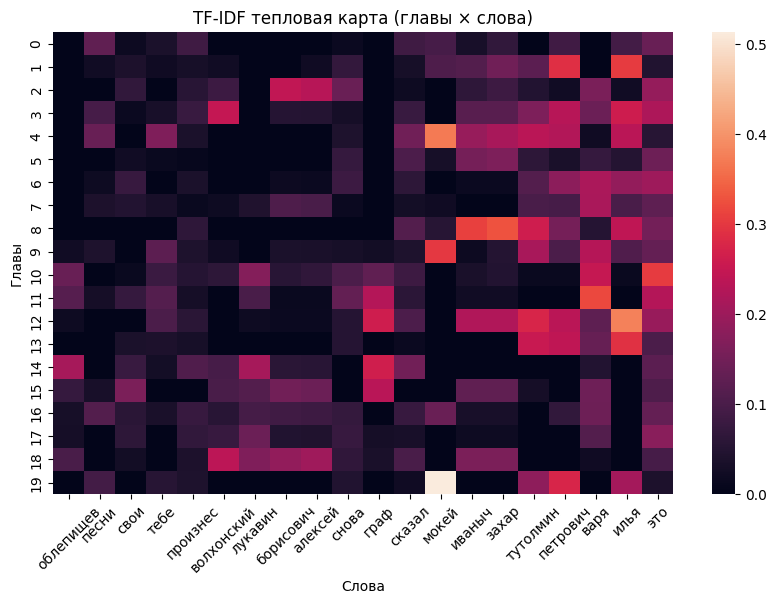

In [97]:
import seaborn as sns
import numpy as np

# берём только топ-20 слов
mean_scores = tfidf_matrix.mean(axis=0).A1
top_indices = mean_scores.argsort()[-20:]

top_features = [feature_names[i] for i in top_indices]

heatmap_data = tfidf_matrix[:, top_indices].toarray()

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, xticklabels=top_features, yticklabels=True)

plt.title("TF-IDF тепловая карта (главы × слова)")
plt.xlabel("Слова")
plt.ylabel("Главы")
plt.xticks(rotation=45)

plt.show()

По тепловой карте, например, можно увидеть, в каких главах какие персонажи появляются в тексте

А тут можно посмотреть динамику слов по главам!

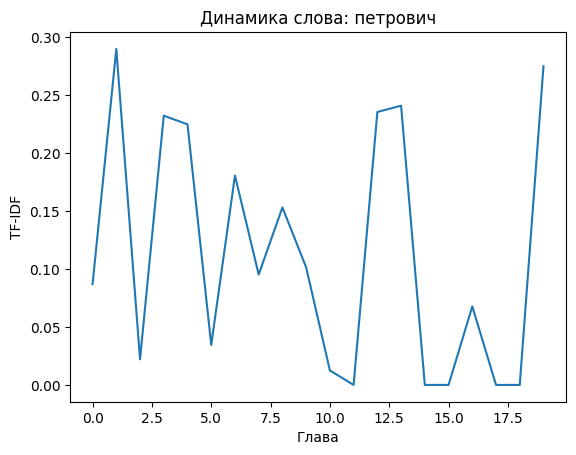

In [108]:
word = "петрович"

if word in feature_names:
    idx = list(feature_names).index(word)
    values = tfidf_matrix[:, idx].toarray().flatten()

    plt.figure()
    plt.plot(values)
    plt.title(f"Динамика слова: {word}")
    plt.xlabel("Глава")
    plt.ylabel("TF-IDF")
    plt.show()

## Теперь будем интерпретировать полученную информацию!

Текст написан в повествовательном стиле, на что указывает преобладание глаголов прошедшего времени (около 80%). Наличие диалогов (реплики с тире), а также вставок, стилизованных под народную речь или песню, как мне кажется, говорит о смешении повествовательной и фольклорной формы. Получеется своего рода реалистическая проза с вкраплением элементов народной стилизации.

Скорее всего, мы имеем дело с романом или повестью в традициях русского реализма!

Лексический анализ (а именно наличие слов «барин», «ямщик», использование отчеств — «Илья Петрович», «Борисович») указывает на дореволюционную Россию, предположительно XIX век.

Высокая частотность имён собственных и социально маркированных обращений свидетельствует о тексте, в котором важна социальная структура общества.

Анализ TF-IDF выявил ключевые слова, связанные с:

* персонажами (Илья, Варя (главный персонаж нашей книги, судя по облаку слов!), Захар и др.)

* социальными ролями (барин, ямщик)

* действиями и коммуникацией (сказал, произнёс)

Дополнительно отметим наличие песенных или фольклорных вставок, что еще раз подчеркивает важность мотива русской народной культуры!

Наконец, морфологический анализ позволяет определить, что в произведении сделан акцент объекты, персонажей и их отношения (о чем нам говорит высокая доля существительных в тексте), а также на сочетании *действия* и *описания* (вывод сделан на основе преобладания именительного и родительного падежей существительных)

### Таким образом, текст можно охарактеризовать как реалистическое прозаическое произведение XIX века, ориентированное на изображение отечественной социальной жизни и взаимодействия персонажей, с элементами народного оттенка стиля.

### Анализ на разных уровнях (лексическом, морфологическом) указывает на классическую повествовательную прозу с выраженной социальной проблематикой (*социальная проблематика, скорее всего, связана с положением крестьян в обществе, ну это я просто предположил интуитивно*).